# QuickCart Warehouse Inventory Stockout Risk
## Supervised Machine Learning Classification Project



## 1. Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

In [23]:
import os, glob, zipfile, shutil

os.makedirs("/content/data", exist_ok=True)

# Automatically find the uploaded ZIP file
zip_files = glob.glob("/content/*.zip")

print("ZIP files found:", zip_files)

for z in zip_files:
    with zipfile.ZipFile(z, "r") as zip_ref:
        zip_ref.extractall("/content/extracted")

# Find all CSV files and put them in /content/data
csv_files = glob.glob("/content/extracted/**/*.csv", recursive=True)

for f in csv_files:
    shutil.copy(f, "/content/data/" + os.path.basename(f))

print("\nCSV files ready:")
print(os.listdir("/content/data"))

ZIP files found: ['/content/quickcart.zip']

CSV files ready:
['dim_events.csv', 'dim_skus.csv', 'QuickCart_Stockout_Risk_Project_Spec.pdf', 'fact_inventory_daily.csv', 'dim_suppliers.csv', 'dim_events.zip', 'dim_stores.csv']


In [24]:
!unzip -o "/content/data/dim_events.zip" -d /content/data

Archive:  /content/data/dim_events.zip
  inflating: /content/data/dim_events.csv  
  inflating: /content/data/dim_skus.csv  
  inflating: /content/data/dim_stores.csv  
  inflating: /content/data/dim_suppliers.csv  
  inflating: /content/data/fact_inventory_daily.csv  


In [25]:
!ls /content/data

dim_events.csv	dim_suppliers.csv
dim_events.zip	fact_inventory_daily.csv
dim_skus.csv	QuickCart_Stockout_Risk_Project_Spec.pdf
dim_stores.csv


## 2. Load the Five Tables


In [26]:
DATA_PATH = "/content/data/"

stores = pd.read_csv(DATA_PATH + "dim_stores.csv")
skus = pd.read_csv(DATA_PATH + "dim_skus.csv")
suppliers = pd.read_csv(DATA_PATH + "dim_suppliers.csv", na_values=["N/A", "missing", "--", "NA", "null"], keep_default_na=True)
events = pd.read_csv(DATA_PATH + "dim_events.csv")
fact = pd.read_csv(DATA_PATH + "fact_inventory_daily.csv")

print("Stores:", stores.shape)
print("SKUs:", skus.shape)
print("Suppliers:", suppliers.shape)
print("Events:", events.shape)
print("Fact:", fact.shape)

Stores: (12, 8)
SKUs: (60, 9)
Suppliers: (15, 6)
Events: (30, 5)
Fact: (21600, 16)


## 3. Locked Sanity Checks


In [27]:
assert len(stores) == 12
assert len(skus) == 60
assert len(suppliers) == 15
assert len(events) == 30
assert len(fact) == 21600

print("Date range:", fact["date"].min(), "to", fact["date"].max())
print("Unique dates:", fact["date"].nunique())
print("\nTarget distribution:")
print(fact["stockout_risk"].value_counts())
print((fact["stockout_risk"].value_counts(normalize=True)*100).round(2))

Date range: 2026-10-01 to 2026-10-30
Unique dates: 30

Target distribution:
stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64
stockout_risk
Safe        65.42
At-Risk     24.01
Imminent    10.57
Name: proportion, dtype: float64


## 4. Data Quality Checks


In [28]:
print("Missing values in each table:\n")
for name, df in {"stores":stores, "skus":skus, "suppliers":suppliers, "events":events, "fact":fact}.items():
    print("\n", name)
    print(df.isna().sum()[df.isna().sum() > 0])

# Standardize display-only city field
stores["city_display"] = stores["city_display"].str.strip().str.title()

# Reliability should be numeric; impute missing values with median
suppliers["reliability_score"] = pd.to_numeric(suppliers["reliability_score"], errors="coerce")
reliability_median = suppliers["reliability_score"].median()
suppliers["supplier_reliability_clean"] = suppliers["reliability_score"].fillna(reliability_median)

print("\nSupplier reliability median used for imputation:", reliability_median)

Missing values in each table:


 stores
Series([], dtype: int64)

 skus
Series([], dtype: int64)

 suppliers
reliability_score    3
dtype: int64

 events
Series([], dtype: int64)

 fact
lead_time_days_actual    19899
dtype: int64

Supplier reliability median used for imputation: 0.725


## 5. Merge the Multi-Table Dataset

In [29]:
fact["date"] = pd.to_datetime(fact["date"])
events["date"] = pd.to_datetime(events["date"])

# Remove duplicate supplier_id from SKU/store joins by selecting needed columns
df = fact.merge(stores, on="store_id", how="left")
df = df.merge(skus.drop(columns=["supplier_id"]), on="sku_id", how="left")
df = df.merge(suppliers.drop(columns=["reliability_score"]), on="supplier_id", how="left")
df = df.merge(events, on="date", how="left")

print("Final merged shape:", df.shape)
print("Missing values after joins:", df.isna().sum().sum())
df.head()

Final merged shape: (21600, 39)
Missing values after joins: 19899


,date,store_id,sku_id,supplier_id,opening_stock,units_demanded,units_sold,closing_stock,reorder_point,reorder_placed,lead_time_days_expected,lead_time_days_actual,sales_velocity_7d,days_of_cover,is_festival_week,stockout_risk,city,city_display,city_tier,store_size,sqft,opened_year,baseline_daily_orders,sku_name,category,unit_price_inr,shelf_life_days,is_perishable,festive_relevant,popularity_tier,supplier_name,categories_supplied,base_lead_time_days,lead_time_variance_days,supplier_reliability_clean,event_name,event_type,demand_multiplier_festive,demand_multiplier_other
0,2026-10-01,ST01,SKU001,SUP11,159.9,15,15.0,144.9,36.4,N,1,NaN,15.00,9.66,N,Safe,Mumbai,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",1,2.5,0.83,Regular Day,none,1.0,1.0
1,2026-10-02,ST01,SKU001,SUP11,144.9,10,10.0,134.9,36.4,N,1,NaN,12.50,10.79,N,Safe,Mumbai,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",1,2.5,0.83,Regular Day,none,1.0,1.0
2,2026-10-03,ST01,SKU001,SUP11,134.9,15,15.0,119.9,36.4,N,1,NaN,13.33,8.99,N,Safe,Mumbai,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",1,2.5,0.83,Regular Day,none,1.0,1.0
3,2026-10-04,ST01,SKU001,SUP11,119.9,10,10.0,109.9,36.4,N,1,NaN,12.50,8.79,N,Safe,Mumbai,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",1,2.5,0.83,Regular Day,none,1.0,1.0
4,2026-10-05,ST01,SKU001,SUP11,109.9,9,9.0,100.9,36.4,N,1,NaN,11.80,8.55,N,Safe,Mumbai,Mumbai,Tier1,Large,2946,2023,580,Banana 1kg,Fruits & Vegetables,132.04,2,Y,N,Low,Coastal Foods Pvt Ltd,"Snacks, Fruits & Vegetables",1,2.5,0.83,Regular Day,none,1.0,1.0


## 6. Exploratory Data Analysis (EDA)

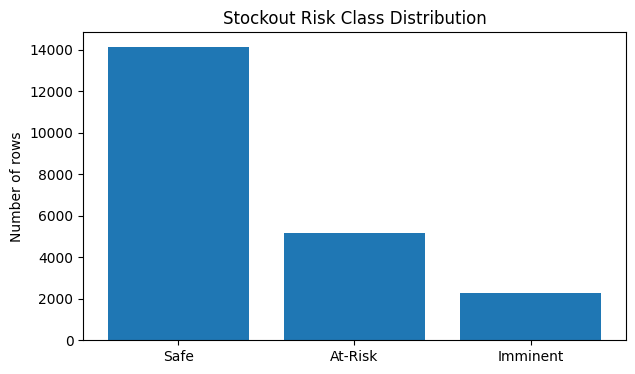

stockout_risk
Safe        65.42
At-Risk     24.01
Imminent    10.57
Name: count, dtype: float64


In [30]:
risk_order = ["Safe", "At-Risk", "Imminent"]
risk_counts = df["stockout_risk"].value_counts().reindex(risk_order)
plt.figure(figsize=(7,4))
plt.bar(risk_counts.index, risk_counts.values)
plt.title("Stockout Risk Class Distribution")
plt.ylabel("Number of rows")
plt.show()

print((risk_counts / len(df) * 100).round(2))

In [31]:
# Festival effect
festival_rate = pd.crosstab(df["is_festival_week"], df["stockout_risk"], normalize="index") * 100
print("Festival week risk distribution (%):")
print(festival_rate.round(2))

# Perishable effect
perishable_rate = pd.crosstab(df["is_perishable"], df["stockout_risk"], normalize="index") * 100
print("\nPerishable risk distribution (%):")
print(perishable_rate.round(2))

Festival week risk distribution (%):
stockout_risk     At-Risk  Imminent   Safe
is_festival_week                          
N                   24.19      9.51  66.30
Y                   21.80     23.31  54.89

Perishable risk distribution (%):
stockout_risk  At-Risk  Imminent   Safe
is_perishable                          
N                24.64      9.30  66.06
Y                22.92     12.77  64.32


## 7. Feature Engineering


In [32]:
# How far stock is from the reorder trigger
df["reorder_gap"] = df["reorder_point"] - df["closing_stock"]

# Normalize stock cover by expected supplier wait
df["days_of_cover_ratio"] = df["days_of_cover"] / df["lead_time_days_expected"].replace(0, np.nan)
df["days_of_cover_ratio"] = df["days_of_cover_ratio"].replace([np.inf, -np.inf], np.nan)

# Calendar features
df["day_of_month"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

# Days since the start of Diwali week (0 before Oct 22)
festival_start = pd.Timestamp("2026-10-22")
df["days_since_festival_start"] = (df["date"] - festival_start).dt.days.clip(lower=0)

# Recent reorder feature: whether a reorder happened in the previous 3 days
df = df.sort_values(["store_id", "sku_id", "date"]).reset_index(drop=True)
reorder_num = (df["reorder_placed"] == "Y").astype(int)
df["is_recent_reorder"] = (
    reorder_num.groupby([df["store_id"], df["sku_id"]])
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).max())
    .fillna(0).astype(int)
)

# Convert binary Y/N fields
for col in ["reorder_placed", "is_festival_week", "is_perishable", "festive_relevant"]:
    df[col] = df[col].map({"Y":1, "N":0})

df[["reorder_gap", "days_of_cover_ratio", "day_of_month", "is_recent_reorder"]].head()

,reorder_gap,days_of_cover_ratio,day_of_month,is_recent_reorder
0,-108.5,9.66,1,0
1,-98.5,10.79,2,0
2,-83.5,8.99,3,0
3,-73.5,8.79,4,0
4,-64.5,8.55,5,0


## 8. Train/Test Split (Time-Based)


In [33]:
train_df = df[df["date"] <= "2026-10-23"].copy()
test_df = df[df["date"] >= "2026-10-24"].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain target distribution (%):")
print((train_df.stockout_risk.value_counts(normalize=True)*100).round(2))
print("\nTest target distribution (%):")
print((test_df.stockout_risk.value_counts(normalize=True)*100).round(2))

Train shape: (16560, 45)
Test shape: (5040, 45)

Train target distribution (%):
stockout_risk
Safe        66.38
At-Risk     24.52
Imminent     9.11
Name: proportion, dtype: float64

Test target distribution (%):
stockout_risk
Safe        62.28
At-Risk     22.34
Imminent    15.38
Name: proportion, dtype: float64


## 9. Select Features


In [34]:
target = "stockout_risk"

features = [
    "opening_stock", "closing_stock", "units_demanded", "units_sold",
    "reorder_point", "reorder_placed", "lead_time_days_expected",
    "sales_velocity_7d", "days_of_cover", "is_festival_week",
    "store_size", "sqft", "baseline_daily_orders",
    "category", "unit_price_inr", "shelf_life_days", "is_perishable",
    "festive_relevant", "popularity_tier",
    "supplier_reliability_clean", "base_lead_time_days", "lead_time_variance_days",
    "event_type", "demand_multiplier_festive", "demand_multiplier_other",
    "reorder_gap", "days_of_cover_ratio", "day_of_month", "day_of_week",
    "days_since_festival_start", "is_recent_reorder"
]

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = [col for col in features if col not in cat_cols]
print("Categorical:", cat_cols)
print("Numeric features:", len(num_cols))

Categorical: ['store_size', 'category', 'popularity_tier', 'event_type']
Numeric features: 27


## 10. Majority-Class Baseline


In [35]:
majority_class = y_train.mode()[0]
baseline_pred = np.full(len(y_test), majority_class)
print("Majority class:", majority_class)
print("Baseline accuracy:", round(accuracy_score(y_test, baseline_pred), 4))
print("Baseline Imminent recall:", round(recall_score(y_test, baseline_pred, labels=["Imminent"], average="macro", zero_division=0), 4))

Majority class: Safe
Baseline accuracy: 0.6228
Baseline Imminent recall: 0.0


## 11. Logistic Regression Model

In [36]:
preprocessor_lr = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

lr_model = Pipeline([
    ("preprocessor", preprocessor_lr),
    ("model", LogisticRegression(max_iter=1500, class_weight="balanced", multi_class="auto"))
])

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, lr_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, lr_pred, zero_division=0))

Logistic Regression Accuracy: 0.8688

Classification Report:

              precision    recall  f1-score   support

     At-Risk       0.97      0.43      0.59      1126
    Imminent       0.60      0.99      0.75       775
        Safe       0.96      1.00      0.98      3139

    accuracy                           0.87      5040
   macro avg       0.84      0.80      0.77      5040
weighted avg       0.91      0.87      0.86      5040



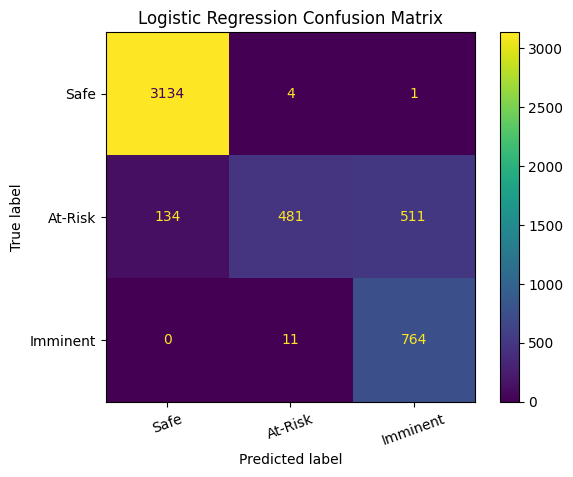

In [37]:
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, labels=risk_order, xticks_rotation=20)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## 12. Random Forest Model


In [38]:
preprocessor_rf = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

rf_model = Pipeline([
    ("preprocessor", preprocessor_rf),
    ("model", RandomForestClassifier(
        n_estimators=250,
        max_depth=18,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred, zero_division=0))

Random Forest Accuracy: 0.9397

Classification Report:

              precision    recall  f1-score   support

     At-Risk       0.83      0.92      0.87      1126
    Imminent       0.87      0.73      0.79       775
        Safe       1.00      1.00      1.00      3139

    accuracy                           0.94      5040
   macro avg       0.90      0.88      0.89      5040
weighted avg       0.94      0.94      0.94      5040



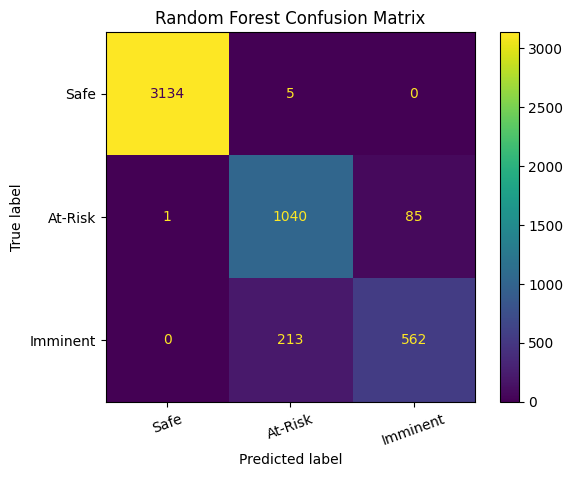

Imminent Recall: 0.7252


In [39]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, labels=risk_order, xticks_rotation=20)
plt.title("Random Forest Confusion Matrix")
plt.show()

print("Imminent Recall:", round(recall_score(y_test, rf_pred, labels=["Imminent"], average="macro"), 4))

## 13. Feature Importance

                            feature  importance
8                num__days_of_cover    0.227061
22         num__days_of_cover_ratio    0.194384
21                 num__reorder_gap    0.176158
1                num__closing_stock    0.063352
0                num__opening_stock    0.033104
16  num__supplier_reliability_clean    0.027620
7            num__sales_velocity_7d    0.026943
4                num__reorder_point    0.022790
5               num__reorder_placed    0.019314
26           num__is_recent_reorder    0.017998
18     num__lead_time_variance_days    0.017702
6      num__lead_time_days_expected    0.017663
3                   num__units_sold    0.017237
17         num__base_lead_time_days    0.016794
2               num__units_demanded    0.016353


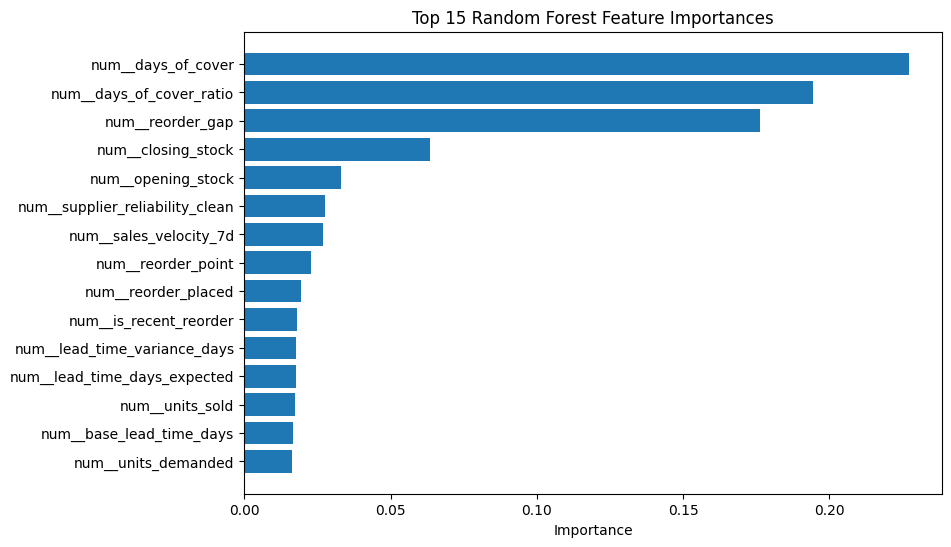

In [40]:
rf = rf_model.named_steps["model"]
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(15))

plt.figure(figsize=(9,6))
top = importance.head(15).sort_values("importance")
plt.barh(top["feature"], top["importance"])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

## 14. Model Comparison

In [41]:
results = pd.DataFrame({
    "Model": ["Majority Baseline", "Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Imminent Recall": [
        recall_score(y_test, baseline_pred, labels=["Imminent"], average="macro", zero_division=0),
        recall_score(y_test, lr_pred, labels=["Imminent"], average="macro", zero_division=0),
        recall_score(y_test, rf_pred, labels=["Imminent"], average="macro", zero_division=0)
    ]
})

results["Accuracy"] = results["Accuracy"].round(4)
results["Imminent Recall"] = results["Imminent Recall"].round(4)
results

,Model,Accuracy,Imminent Recall
0,Majority Baseline,0.6228,0.0000
1,Logistic Regression,0.8688,0.9858
2,Random Forest,0.9397,0.7252


## 15. Business Conclusion

### Key findings
- The dataset has a strong class imbalance, with **Safe** as the majority class.
- Festival days increase demand pressure and should be treated as an important operational signal.
- Stock cover, sales velocity, reorder gap and supplier lead-time/reliability are expected to be major predictors.
- Accuracy alone is not enough: **recall for the Imminent class is especially important** because missing a real stockout can cause lost sales and poor customer experience.

### Recommendation
Use the best model as an **early-warning system**. Flag SKUs predicted as **Imminent** for immediate inventory-team action, while **At-Risk** items can be monitored and prioritized for replenishment planning.